In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [2]:
df_sessions = pd.read_csv("df_all_info.csv")

In [3]:
df_sessions

,id,uri,data,idOrgao,siglaOrgao,aprovacao,descricao,ultimaAberturaVotacao_descricao,ultimaApresentacaoProposicao_descricao,year,...,SDD,SOLIDARIEDADE,Solidaried,UNIÃO,União,author_type,author,session_Type,idProposicao,theme
0,96076-49,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-19,180,PLEN,1.0,Aprovada a Redação Final oferecida pelo Relato...,Votação da Redação Final.,"Parecer Proferido em Plenário, Dep. Luiz Eduar...",2003,...,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Final Wording,96076.0,Esporte e Lazer
1,96076-46,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-19,180,PLEN,1.0,Aprovado o Substitutivo oferecido pelo Relator...,Votação em turno único.,"Parecer Proferido em Plenário, Dep. Luiz Eduar...",2003,...,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Substitutes,96076.0,Esporte e Lazer
2,90170-30,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-26,180,PLEN,1.0,"Aprovado requerimento do Líderes que requer, n...",NaN,Apresentação do Requerimento.,2003,...,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Requests,90170.0,Defesa e Segurança
3,101651-2,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-26,180,PLEN,1.0,Aprovado,NaN,Apresentação do Requerimento.,2003,...,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Final Wording,90170.0,Defesa e Segurança
4,90170-25,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-02-27,180,PLEN,1.0,Aprovada a Redação Final oferecida pelo Relato...,Votação da Redação Final,"Parecer Proferido em Plenário, Dep. Agnaldo Mu...",2003,...,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Final Wording,90170.0,Defesa e Segurança
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36346,2460010-35,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,180,PLEN,0.0,Rejeitado o Requerimento. Sim: 82; Não: 193; T...,NaN,NaN,2024,...,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Requests,2460010.0,Finanças Públicas e Orçamento
36347,2460010-43,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,180,PLEN,1.0,"Aprovado o Projeto de Lei nº 3.802, de 2024. S...",Votação em turno único.,"Parecer proferido em Plenário pelo Relator, De...",2024,...,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Final Wording,2460010.0,Economia
36348,2460010-43,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,180,PLEN,1.0,"Aprovado o Projeto de Lei nº 3.802, de 2024. S...",Votação em turno único.,"Parecer proferido em Plenário pelo Relator, De...",2024,...,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Final Wording,2460010.0,Finanças Públicas e Orçamento
36349,2460010-45,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19,180,PLEN,1.0,Aprovada a Redação Final assinada pelo relator...,Votação da Redação Final.,"Parecer proferido em Plenário pelo Relator, De...",2024,...,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Final Wording,2460010.0,Economia


In [4]:
df_sessions_selected = df_sessions.drop(columns=['id', 'uri', 'data', 'idOrgao', 'siglaOrgao', 'descricao', 'ultimaAberturaVotacao_descricao', 'ultimaApresentacaoProposicao_descricao', 'idProposicao', 'propositionID', 'idVotacao_x'])

In [5]:
df_sessions_selected

,aprovacao,year,AVANTE,Avante,Bl MdbPsdRepPode,Bl MdbPsdRepPodePsc,Bl UniPpFdrPsdbCid...,Bloco Parlamentar,CIDADANIA,Cidadania,...,SD,SDD,SOLIDARIEDADE,Solidaried,UNIÃO,União,author_type,author,session_Type,theme
0,1.0,2003,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Final Wording,Esporte e Lazer
1,1.0,2003,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Substitutes,Esporte e Lazer
2,1.0,2003,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Requests,Defesa e Segurança
3,1.0,2003,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Final Wording,Defesa e Segurança
4,1.0,2003,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Órgão do Poder Executivo,Poder Executivo,Approval of Final Wording,Defesa e Segurança
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36346,0.0,2024,0,0,-1,0,-1,0,0,0,...,0,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Requests,Finanças Públicas e Orçamento
36347,1.0,2024,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Final Wording,Economia
36348,1.0,2024,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Final Wording,Finanças Públicas e Orçamento
36349,1.0,2024,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Deputado(a),José Guimarães,Approval of Final Wording,Economia


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36351 entries, 0 to 36350
Columns: 155 entries, aprovacao to theme
dtypes: float64(1), int64(150), object(4)
memory usage: 43.0+ MB


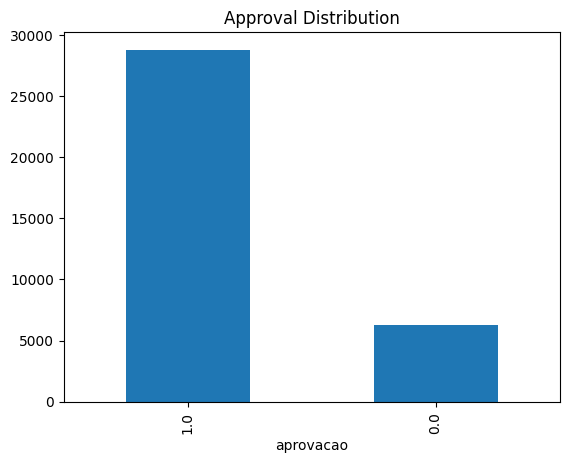

In [6]:
df_sessions_selected.info()
df_sessions_selected.describe()
df_sessions_selected['aprovacao'].value_counts().plot(kind='bar', title="Approval Distribution")
plt.show()

In [7]:
# Check for missing values
print(df_sessions_selected.isnull().sum())

aprovacao           1258
year                   0
AVANTE                 0
Avante                 0
Bl MdbPsdRepPode       0
                    ... 
União                  0
author_type            0
author                 0
session_Type           0
theme                  0
Length: 155, dtype: int64


In [8]:
df_sessions_selected.dropna(inplace=True)

In [9]:
print(df_sessions_selected.isnull().sum())

aprovacao           0
year                0
AVANTE              0
Avante              0
Bl MdbPsdRepPode    0
                   ..
União               0
author_type         0
author              0
session_Type        0
theme               0
Length: 155, dtype: int64


In [10]:
# Encode categorical columns
categorical_cols = ['author_type', 'author', 'session_Type', 'theme']
for col in categorical_cols:
    df_sessions_selected[col] = LabelEncoder().fit_transform(df_sessions_selected[col])

In [11]:
X = df_sessions_selected.drop(columns=['aprovacao'])  # Features
y = df_sessions_selected['aprovacao']  # Target variable

New class distribution:
 aprovacao
1.0    28794
0.0    28794
Name: count, dtype: int64


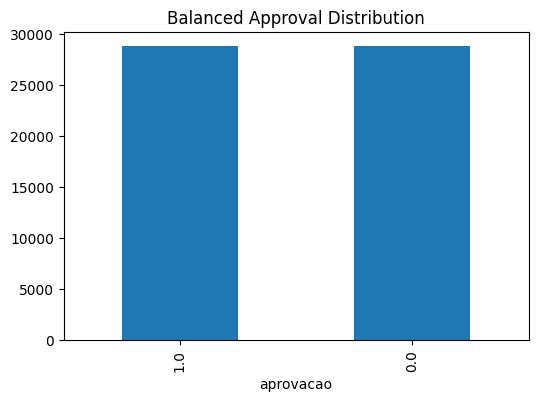

In [12]:
# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check new balance
print("New class distribution:\n", pd.Series(y_resampled).value_counts())

# Plot new distribution
plt.figure(figsize=(6,4))
pd.Series(y_resampled).value_counts().plot(kind='bar', title="Balanced Approval Distribution")
plt.show()

In [14]:
X_resampled

,year,AVANTE,Avante,Bl MdbPsdRepPode,Bl MdbPsdRepPodePsc,Bl UniPpFdrPsdbCid...,Bloco Parlamentar,CIDADANIA,Cidadania,DEM,...,SD,SDD,SOLIDARIEDADE,Solidaried,UNIÃO,União,author_type,author,session_Type,theme
0,2003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,11,765,1,16
1,2003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,11,765,3,16
2,2003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,11,765,2,6
3,2003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,11,765,1,6
4,2003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,11,765,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57583,2020,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,324,3,12
57584,2022,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,1156,3,15
57585,2022,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,157,2,0
57586,2019,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,265,2,10


In [15]:
y_resampled

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
57583    0.0
57584    0.0
57585    0.0
57586    0.0
57587    0.0
Name: aprovacao, Length: 57588, dtype: float64

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# Set up Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [27]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Perform cross-validation
scores = cross_val_score(model, X_resampled, y_resampled, cv=kf, scoring="accuracy")

In [28]:
# Print results
print(f"Accuracy Scores for each fold: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Accuracy Scores for each fold: [0.84120507 0.84702205 0.85023442 0.84596683 0.84136494]
Mean Accuracy: 0.8452
Standard Deviation: 0.0035


In [29]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_scores = cross_val_score(xgb_model, X_resampled, y_resampled, cv=kf, scoring="accuracy")

e:\Anaconda\envs\dados_abertos\lib\site-packages\xgboost\core.py:158: UserWarning: [00:30:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
e:\Anaconda\envs\dados_abertos\lib\site-packages\xgboost\core.py:158: UserWarning: [00:30:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
e:\Anaconda\envs\dados_abertos\lib\site-packages\xgboost\core.py:158: UserWarning: [00:30:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
e:\Anaconda\envs\dados_ab

In [30]:
print(f"XGBoost Accuracy Scores: {xgb_scores}")
print(f"Mean Accuracy: {xgb_scores.mean():.4f}")
print(f"Standard Deviation: {xgb_scores.std():.4f}")

XGBoost Accuracy Scores: [0.84111825 0.84380969 0.83686404 0.83789181 0.83129287]
Mean Accuracy: 0.8382
Standard Deviation: 0.0042


In [33]:
# Train the model again with all data
model.fit(X_resampled, y_resampled)

RandomForestClassifier(random_state=42)

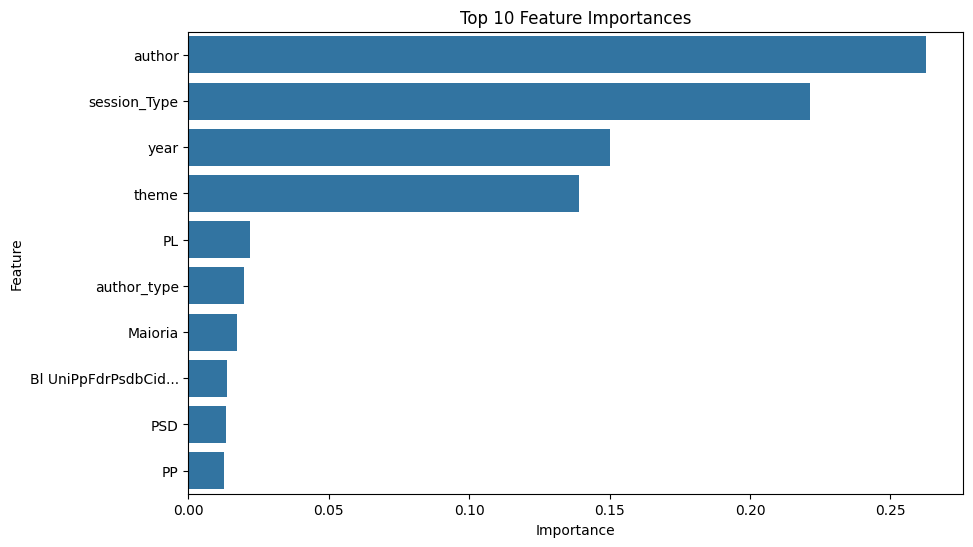

In [36]:
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()

In [103]:
df_session_features = df_sessions[['id','aprovacao', 'year', 'data', 'author', 'session_Type', 'theme']]

df_session_features

,id,aprovacao,year,data,author,session_Type,theme
0,96076-49,1.0,2003,2003-02-19,Poder Executivo,Approval of Final Wording,Esporte e Lazer
1,96076-46,1.0,2003,2003-02-19,Poder Executivo,Approval of Substitutes,Esporte e Lazer
2,90170-30,1.0,2003,2003-02-26,Poder Executivo,Approval of Requests,Defesa e Segurança
3,101651-2,1.0,2003,2003-02-26,Poder Executivo,Approval of Final Wording,Defesa e Segurança
4,90170-25,1.0,2003,2003-02-27,Poder Executivo,Approval of Final Wording,Defesa e Segurança
...,...,...,...,...,...,...,...
36346,2460010-35,0.0,2024,2024-12-19,José Guimarães,Approval of Requests,Finanças Públicas e Orçamento
36347,2460010-43,1.0,2024,2024-12-19,José Guimarães,Approval of Final Wording,Economia
36348,2460010-43,1.0,2024,2024-12-19,José Guimarães,Approval of Final Wording,Finanças Públicas e Orçamento
36349,2460010-45,1.0,2024,2024-12-19,José Guimarães,Approval of Final Wording,Economia


In [104]:
df_author_popularity = pd.read_csv("df_author_popularity.csv")
df_cluster = pd.read_csv("df_clusters.csv")

In [105]:
# Merge author popularity using 'id' from df_session_features and 'idVotacao' from df_author_popularity
df_session_features = df_session_features.merge(
    df_author_popularity[['idVotacao', 'popularity']], 
    left_on='id', 
    right_on='idVotacao', 
    how='left'
)

# Rename the column for clarity
df_session_features.rename(columns={'popularity': 'author_popularity'}, inplace=True)

# Merge session cluster using 'id' from df_session_features and 'idVotacao' from df_cluster
df_session_features = df_session_features.merge(
    df_cluster[['idVotacao', 'Cluster']], 
    left_on='id', 
    right_on='idVotacao', 
    how='left'
)

# Rename the column for clarity
df_session_features.rename(columns={'Cluster': 'session_cluster'}, inplace=True)

# Drop the redundant 'idVotacao' columns from the merges
df_session_features.drop(columns=['idVotacao_x', 'idVotacao_y'], inplace=True, errors='ignore')



In [106]:
df_session_features

,id,aprovacao,year,data,author,session_Type,theme,author_popularity,session_cluster
0,96076-49,1.0,2003,2003-02-19,Poder Executivo,Approval of Final Wording,Esporte e Lazer,NaN,NaN
1,96076-46,1.0,2003,2003-02-19,Poder Executivo,Approval of Substitutes,Esporte e Lazer,NaN,NaN
2,90170-30,1.0,2003,2003-02-26,Poder Executivo,Approval of Requests,Defesa e Segurança,NaN,NaN
3,101651-2,1.0,2003,2003-02-26,Poder Executivo,Approval of Final Wording,Defesa e Segurança,NaN,NaN
4,90170-25,1.0,2003,2003-02-27,Poder Executivo,Approval of Final Wording,Defesa e Segurança,NaN,NaN
...,...,...,...,...,...,...,...,...,...
36346,2460010-35,0.0,2024,2024-12-19,José Guimarães,Approval of Requests,Finanças Públicas e Orçamento,0.427785,3.0
36347,2460010-43,1.0,2024,2024-12-19,José Guimarães,Approval of Final Wording,Economia,0.427785,1.0
36348,2460010-43,1.0,2024,2024-12-19,José Guimarães,Approval of Final Wording,Finanças Públicas e Orçamento,0.427785,1.0
36349,2460010-45,1.0,2024,2024-12-19,José Guimarães,Approval of Final Wording,Economia,NaN,NaN


In [107]:
# Drop rows where 'session_cluster' is NaN
df_session_features = df_session_features.dropna(subset=['session_cluster'])

# Replace NaN values in 'author_popularity' with 0
df_session_features['author_popularity'] = df_session_features['author_popularity'].fillna(0)

df_session_features

C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_15680\602776799.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_session_features['author_popularity'] = df_session_features['author_popularity'].fillna(0)


,id,aprovacao,year,data,author,session_Type,theme,author_popularity,session_cluster
284,143282-5,1.0,2003,2003-11-18,Osmar Serraglio,Approval of Requests,Economia,0.000000,1.0
285,143282-5,1.0,2003,2003-11-18,Osmar Serraglio,Approval of Requests,Educação,0.000000,1.0
294,145211-10,1.0,2003,2003-11-26,Poder Executivo,Approval of Requests,Finanças Públicas e Orçamento,0.000000,4.0
339,150930-5,1.0,2004,2004-01-21,Poder Executivo,Approval of Requests,Administração Pública,0.792553,4.0
340,151030-5,1.0,2004,2004-01-21,Poder Executivo,Approval of Requests,Saúde,0.792553,4.0
...,...,...,...,...,...,...,...,...,...
36290,2473375-78,NaN,2024,2024-12-19,Márcio Jerry,Approval of Final Wording,Previdência e Assistência Social,0.580435,1.0
36345,2460010-35,0.0,2024,2024-12-19,José Guimarães,Approval of Requests,Economia,0.427785,3.0
36346,2460010-35,0.0,2024,2024-12-19,José Guimarães,Approval of Requests,Finanças Públicas e Orçamento,0.427785,3.0
36347,2460010-43,1.0,2024,2024-12-19,José Guimarães,Approval of Final Wording,Economia,0.427785,1.0


In [108]:
df_session_new_predict = df_session_features.drop(columns=['id', 'data', 'session_cluster'])
df_session_new_predict

,aprovacao,year,author,session_Type,theme,author_popularity
284,1.0,2003,Osmar Serraglio,Approval of Requests,Economia,0.000000
285,1.0,2003,Osmar Serraglio,Approval of Requests,Educação,0.000000
294,1.0,2003,Poder Executivo,Approval of Requests,Finanças Públicas e Orçamento,0.000000
339,1.0,2004,Poder Executivo,Approval of Requests,Administração Pública,0.792553
340,1.0,2004,Poder Executivo,Approval of Requests,Saúde,0.792553
...,...,...,...,...,...,...
36290,NaN,2024,Márcio Jerry,Approval of Final Wording,Previdência e Assistência Social,0.580435
36345,0.0,2024,José Guimarães,Approval of Requests,Economia,0.427785
36346,0.0,2024,José Guimarães,Approval of Requests,Finanças Públicas e Orçamento,0.427785
36347,1.0,2024,José Guimarães,Approval of Final Wording,Economia,0.427785


<class 'pandas.core.frame.DataFrame'>
Index: 5397 entries, 284 to 36348
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   aprovacao          4765 non-null   float64
 1   year               5397 non-null   int64  
 2   author             5397 non-null   object 
 3   session_Type       5397 non-null   object 
 4   theme              5397 non-null   object 
 5   author_popularity  5397 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 295.1+ KB


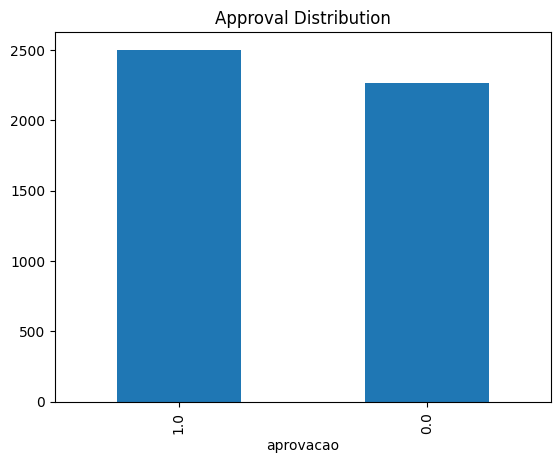

In [109]:
df_session_new_predict.info()
df_session_new_predict.describe()
df_session_new_predict['aprovacao'].value_counts().plot(kind='bar', title="Approval Distribution")
plt.show()

In [110]:
# Check for missing values
print(df_session_new_predict.isnull().sum())

aprovacao            632
year                   0
author                 0
session_Type           0
theme                  0
author_popularity      0
dtype: int64


In [111]:
df_session_new_predict.dropna(inplace=True)
df_session_new_predict

,aprovacao,year,author,session_Type,theme,author_popularity
284,1.0,2003,Osmar Serraglio,Approval of Requests,Economia,0.000000
285,1.0,2003,Osmar Serraglio,Approval of Requests,Educação,0.000000
294,1.0,2003,Poder Executivo,Approval of Requests,Finanças Públicas e Orçamento,0.000000
339,1.0,2004,Poder Executivo,Approval of Requests,Administração Pública,0.792553
340,1.0,2004,Poder Executivo,Approval of Requests,Saúde,0.792553
...,...,...,...,...,...,...
36236,1.0,2024,Márcio Jerry,Approval of Substitutes,Previdência e Assistência Social,0.580435
36345,0.0,2024,José Guimarães,Approval of Requests,Economia,0.427785
36346,0.0,2024,José Guimarães,Approval of Requests,Finanças Públicas e Orçamento,0.427785
36347,1.0,2024,José Guimarães,Approval of Final Wording,Economia,0.427785


In [112]:
print(df_session_new_predict.isnull().sum())

aprovacao            0
year                 0
author               0
session_Type         0
theme                0
author_popularity    0
dtype: int64


In [113]:
# Encode categorical columns
categorical_cols = ['author', 'session_Type', 'theme']
for col in categorical_cols:
    df_session_new_predict[col] = LabelEncoder().fit_transform(df_session_new_predict[col])

In [114]:
X = df_session_new_predict.drop(columns=['aprovacao'])  # Features
y = df_session_new_predict['aprovacao']  # Target variable

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [116]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [117]:
# Set up Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [118]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Perform cross-validation
scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

In [119]:
# Print results
print(f"Accuracy Scores for each fold: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Accuracy Scores for each fold: [0.79223505 0.83105981 0.81427072 0.82266527 0.82056663]
Mean Accuracy: 0.8162
Standard Deviation: 0.0131


In [120]:
# Train the model again with all data
model.fit(X, y)

RandomForestClassifier(random_state=42)

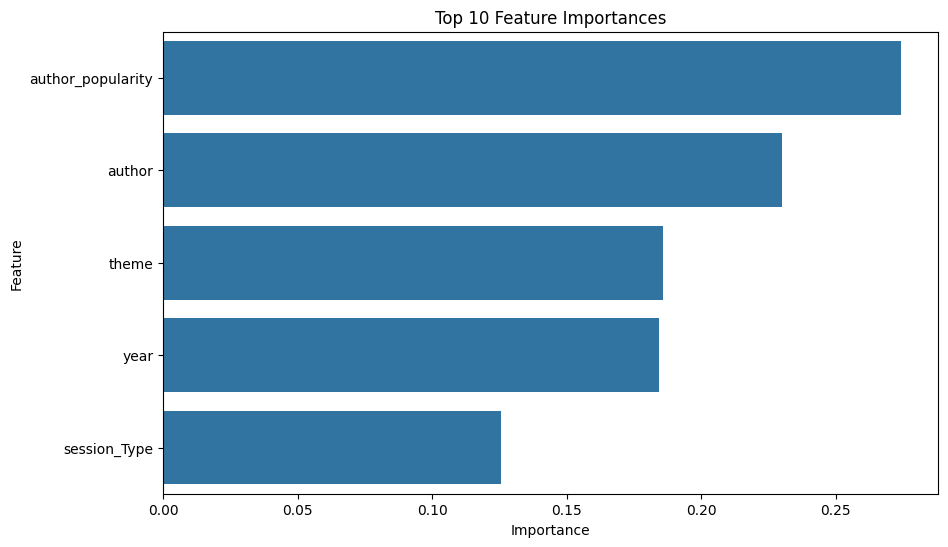

In [121]:
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()